# Dataset Overview — Pasca Preprocessing

**Prediksi Ketepatan Lulus Mahasiswa — 17 Fitur + 1 Target, 608 Mahasiswa, 0 NULLs**


## 1. Dataset Summary

Memuat data, menampilkan dimensi, tipe data, statistik deskriptif, dan distribusi target.


In [44]:
# Cell 1: Load & Summary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_palette('Set2')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {0: '#E74C3C', 1: '#2ECC71'}

df = pd.read_csv('dataset_clean.csv')
print(f'Shape: {df.shape}')
print(f'Total rows: {df.shape[0]}')
print(f'Total features: {df.shape[1] - 1}')
print(f'Target classes: {df["target"].nunique()}')
print(f'NULL values: {df.isnull().sum().sum()}')
print()
print('=' * 60)
print('Target Distribution')
print('=' * 60)
print(df['target'].value_counts())
print()
print(df['target'].value_counts(normalize=True).mul(100).round(2))
print()
print('=' * 60)
print('Data Types')
print('=' * 60)
print(df.dtypes)
print()
print('=' * 60)
print('Descriptive Statistics')
print('=' * 60)
display(df.describe().round(3))


Shape: (608, 17)
Total rows: 608
Total features: 16
Target classes: 2
NULL values: 0

Target Distribution
target
1    540
0     68
Name: count, dtype: int64

target
1    88.82
0    11.18
Name: proportion, dtype: float64

Data Types
angkatan                  int64
program                   int64
ips_sem1                float64
ips_sem2                float64
ips_sem3                float64
sks_sem1                float64
sks_sem2                float64
sks_sem3                float64
failed_courses            int64
failed_in_sem1            int64
repeated_courses          int64
ips_trend               float64
avg_ips                 float64
ips_std                 float64
ips_min                 float64
sks_completion_ratio    float64
target                    int64
dtype: object

Descriptive Statistics


,angkatan,program,ips_sem1,ips_sem2,ips_sem3,sks_sem1,sks_sem2,sks_sem3,failed_courses,failed_in_sem1,repeated_courses,ips_trend,avg_ips,ips_std,ips_min,sks_completion_ratio,target
count,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000,608.000
mean,2019.176,0.758,3.148,3.225,3.525,14.434,13.688,12.026,0.416,0.067,0.419,0.377,3.299,0.301,3.046,0.669,0.888
std,2.931,0.429,0.234,0.378,0.438,8.242,5.864,6.568,2.033,0.514,0.904,0.498,0.243,0.233,0.375,0.276,0.315
min,2015.000,0.000,1.300,0.570,0.300,2.000,2.000,1.000,0.000,0.000,0.000,-2.790,1.680,0.000,0.300,0.117,0.000
25%,2016.000,1.000,3.070,3.130,3.200,2.000,9.000,6.000,0.000,0.000,0.000,0.000,3.182,0.124,3.000,0.333,1.000
50%,2020.000,1.000,3.100,3.240,3.670,20.000,16.000,9.000,0.000,0.000,0.000,0.450,3.343,0.287,3.070,0.700,1.000
75%,2022.000,1.000,3.225,3.320,3.830,20.000,18.000,20.000,0.000,0.000,1.000,0.760,3.410,0.405,3.140,0.933,1.000
max,2023.000,1.000,4.000,4.000,4.000,24.000,22.000,22.000,18.000,7.000,12.000,2.500,3.897,1.804,3.800,1.067,1.000


## 2. Distribusi Target

**Tepat Waktu (1):** 540 (88.8%)  
**Tidak Tepat (0):** 68 (11.2%)


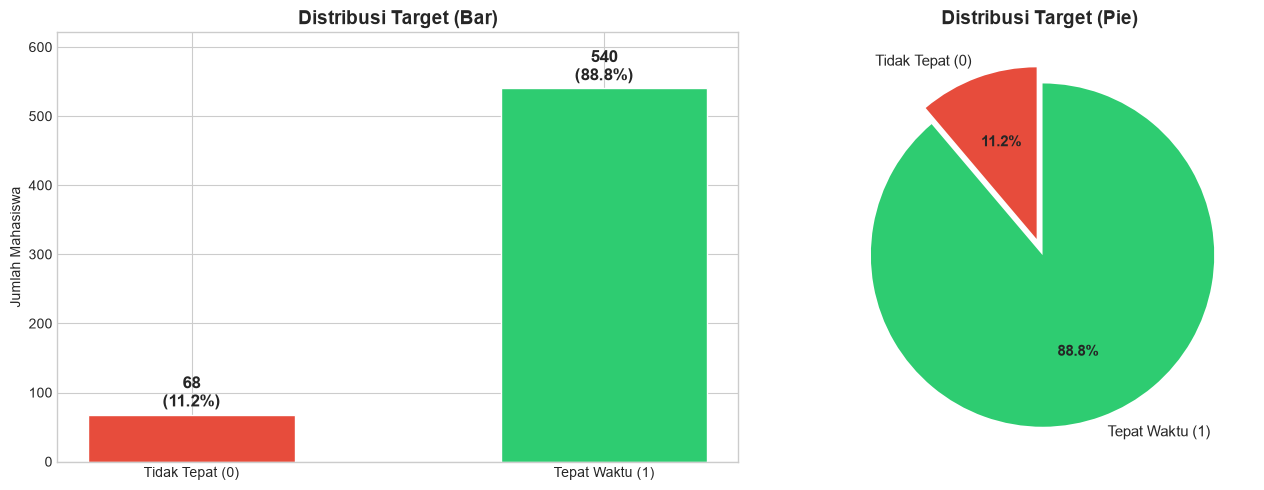

Tepat Waktu (1): 540 (88.8%)
Tidak Tepat (0): 68 (11.2%)


In [45]:
# Cell 2: Target Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

count_0 = (df['target'] == 0).sum()
count_1 = (df['target'] == 1).sum()
counts = [count_0, count_1]
pcts = [count_0 / len(df) * 100, count_1 / len(df) * 100]
labels = ['Tidak Tepat (0)', 'Tepat Waktu (1)']
colors_list = [COLORS[0], COLORS[1]]

# Bar chart
bars = ax1.bar(labels, counts, color=colors_list, edgecolor='white', width=0.5)
for bar, count, pct in zip(bars, counts, pcts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_title('Distribusi Target (Bar)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Jumlah Mahasiswa')
ax1.set_ylim(0, max(counts) * 1.15)

# Pie chart
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, autopct='%1.1f%%',
    colors=colors_list, startangle=90, explode=(0.05, 0.05),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Distribusi Target (Pie)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Tepat Waktu (1): {count_1} ({pcts[1]:.1f}%)')
print(f'Tidak Tepat (0): {count_0} ({pcts[0]:.1f}%)')


## 3. Distribusi Fitur — IPS

Histogram *overlay* untuk `ips_sem1`, `ips_sem2`, `ips_sem3` dibedakan berdasarkan kelas target.


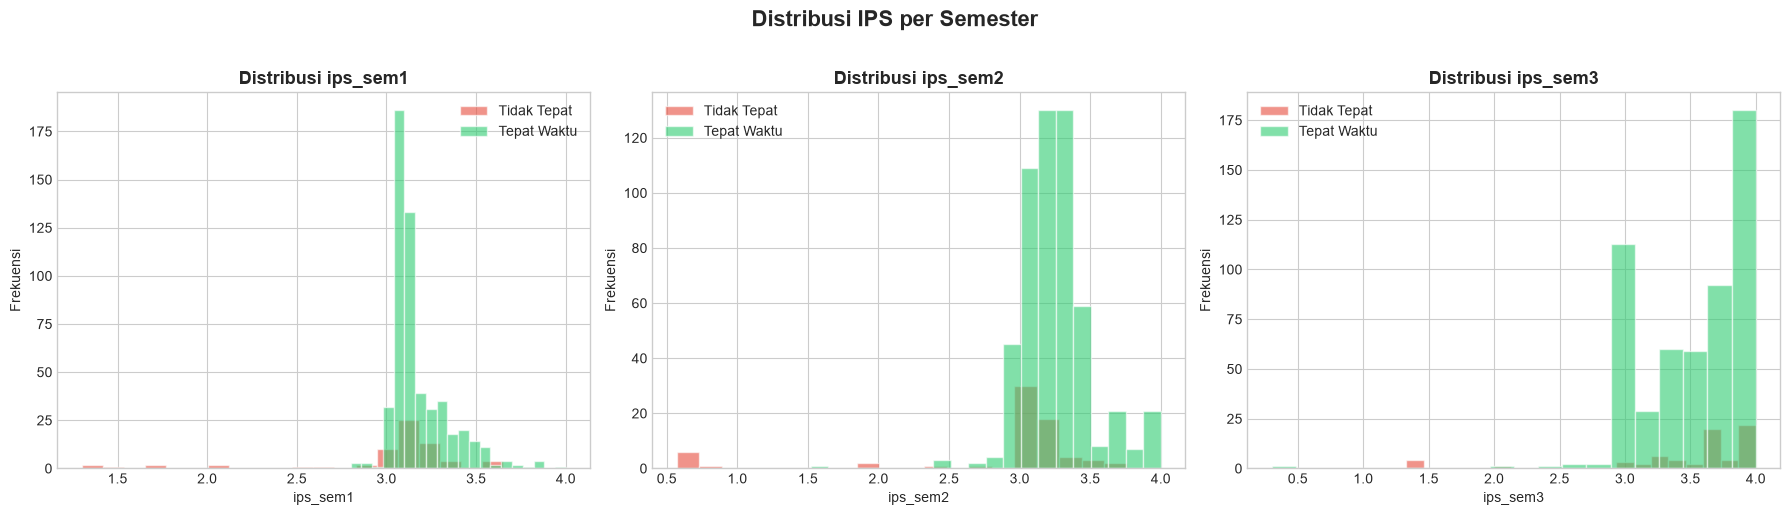

In [46]:
# Cell 3: IPS Feature Distributions
ips_cols = ['ips_sem1', 'ips_sem2', 'ips_sem3']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ips_cols):
    for target_val in [0, 1]:
        subset = df[df['target'] == target_val][col]
        label = 'Tidak Tepat' if target_val == 0 else 'Tepat Waktu'
        ax.hist(subset, bins=20, alpha=0.6, color=COLORS[target_val],
                label=label, density=False, edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=10)

fig.suptitle('Distribusi IPS per Semester', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Distribusi Fitur — SKS

Histogram *overlay* untuk `sks_sem1`, `sks_sem2`, `sks_sem3`.


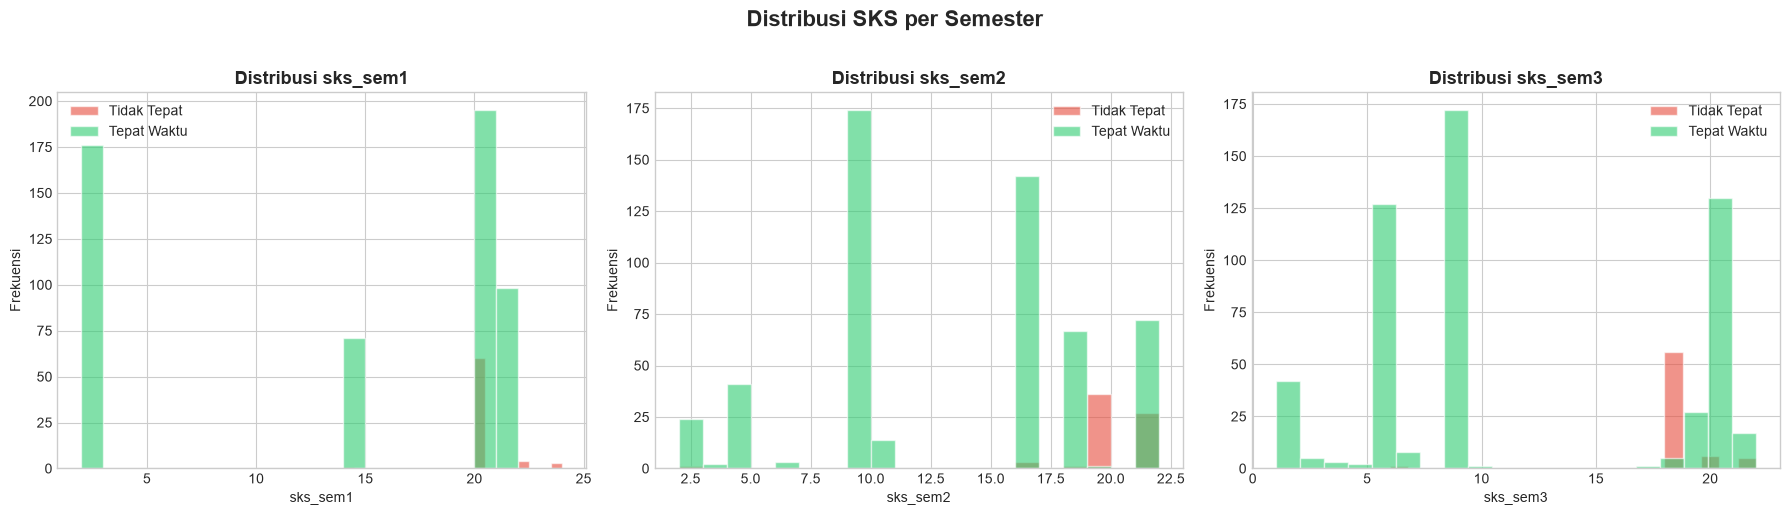

In [47]:
# Cell 4: SKS Feature Distributions
sks_cols = ['sks_sem1', 'sks_sem2', 'sks_sem3']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, sks_cols):
    for target_val in [0, 1]:
        subset = df[df['target'] == target_val][col]
        label = 'Tidak Tepat' if target_val == 0 else 'Tepat Waktu'
        ax.hist(subset, bins=20, alpha=0.6, color=COLORS[target_val],
                label=label, density=False, edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=10)

fig.suptitle('Distribusi SKS per Semester', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Distribusi Fitur — Grade

Fitur terkait kegagalan (`failed_courses`, `failed_in_sem1`, `repeated_courses`) bersifat *zero-inflated*. Disajikan dengan *log scale* pada sumbu Y.


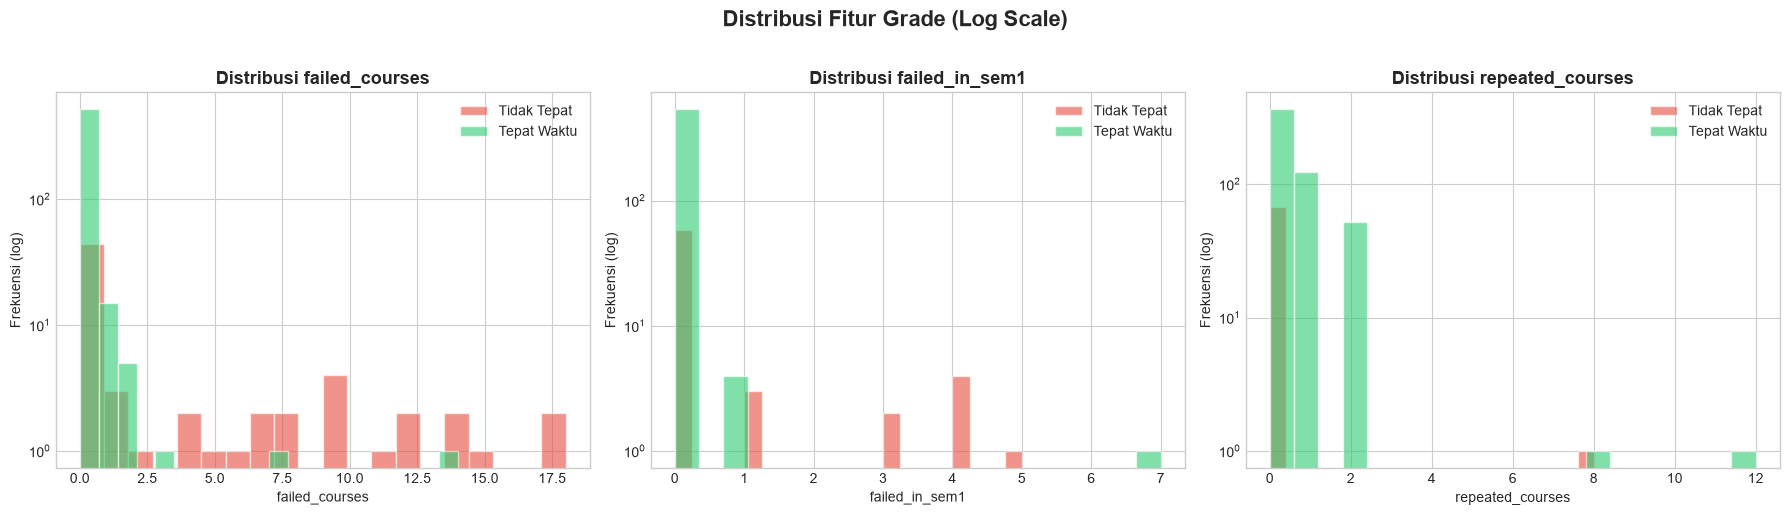

In [48]:
# Cell 5: Grade Feature Distributions
grade_cols = ['failed_courses', 'failed_in_sem1', 'repeated_courses']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, grade_cols):
    for target_val in [0, 1]:
        subset = df[df['target'] == target_val][col]
        label = 'Tidak Tepat' if target_val == 0 else 'Tepat Waktu'
        ax.hist(subset, bins=20, alpha=0.6, color=COLORS[target_val],
                label=label, density=False, edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi (log)')
    ax.set_yscale('log')
    ax.legend(fontsize=10)

fig.suptitle('Distribusi Fitur Grade (Log Scale)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Distribusi Fitur — Derived Features

Fitur turunan: `ips_trend`, `avg_ips`, `ips_std`, `ips_min`, `sks_completion_ratio`.


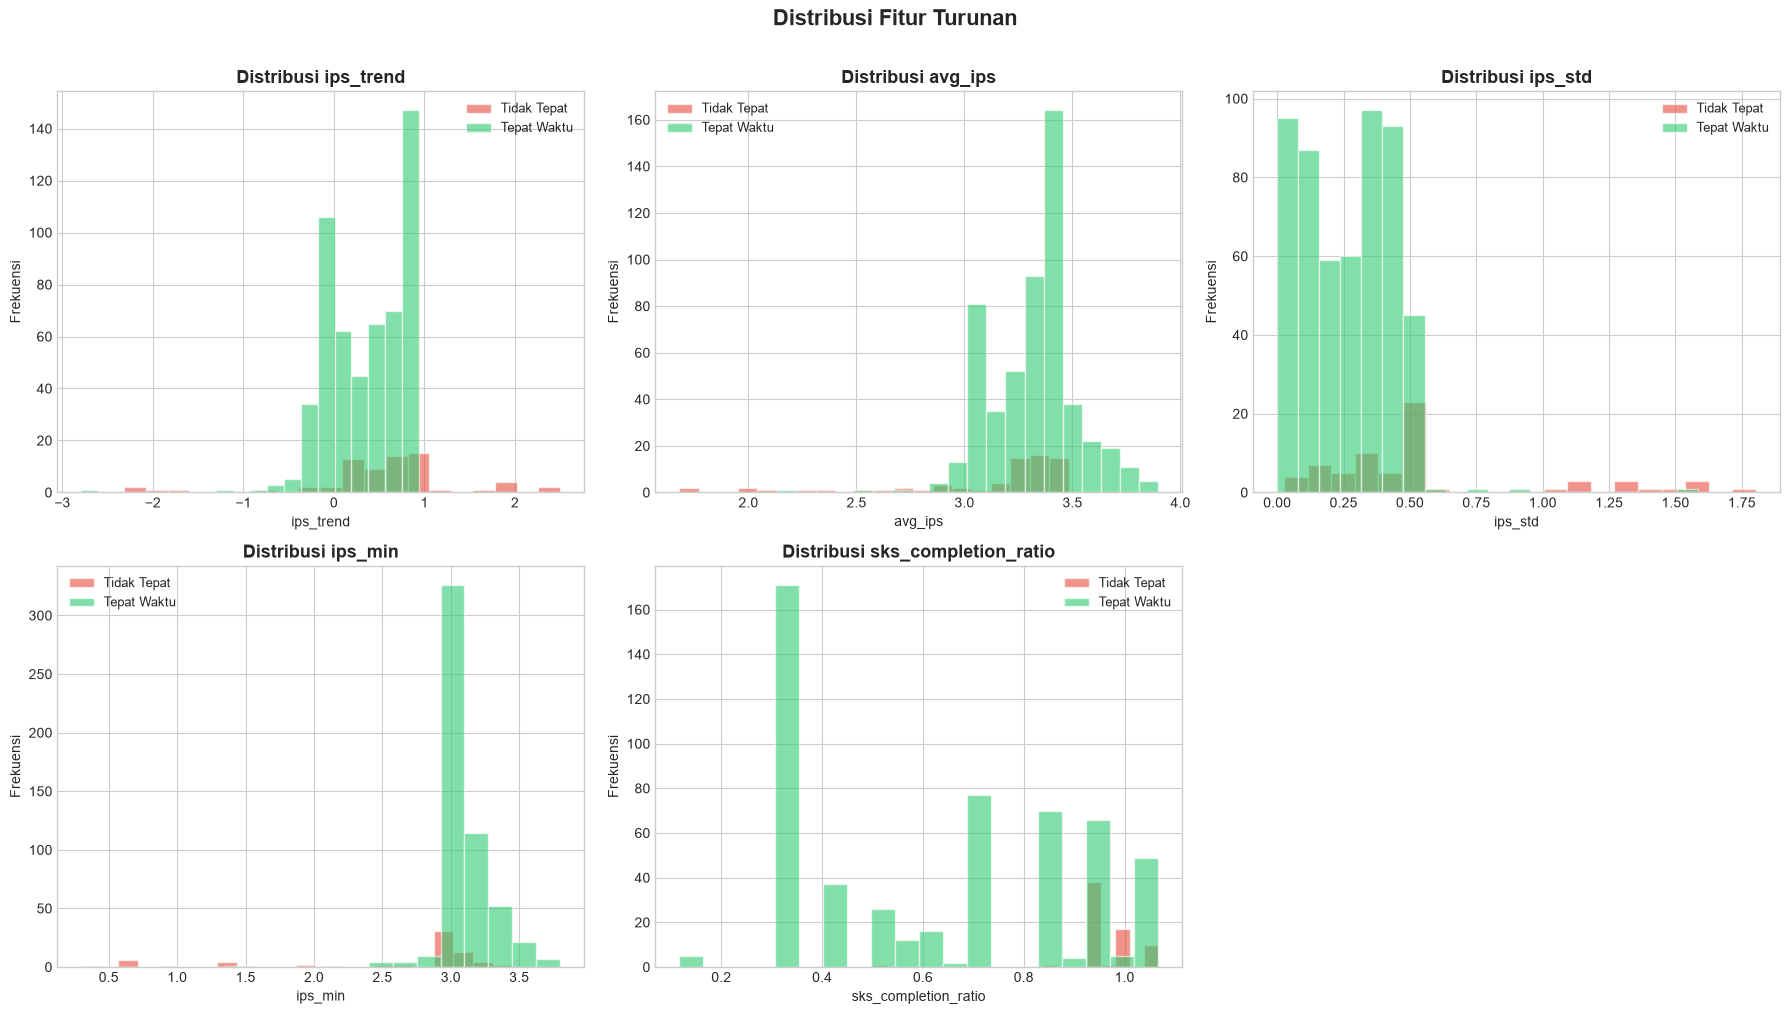

In [49]:
# Cell 6: Derived Feature Distributions
derived_cols = ['ips_trend', 'avg_ips', 'ips_std', 'ips_min', 'sks_completion_ratio']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(derived_cols):
    ax = axes[i]
    for target_val in [0, 1]:
        subset = df[df['target'] == target_val][col]
        label = 'Tidak Tepat' if target_val == 0 else 'Tepat Waktu'
        ax.hist(subset, bins=20, alpha=0.6, color=COLORS[target_val],
                label=label, density=False, edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)

# Hide the unused 6th subplot
axes[5].set_visible(False)

fig.suptitle('Distribusi Fitur Turunan', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 7. Correlation Heatmap

Matriks korelasi Pearson seluruh fitur numerik + target.


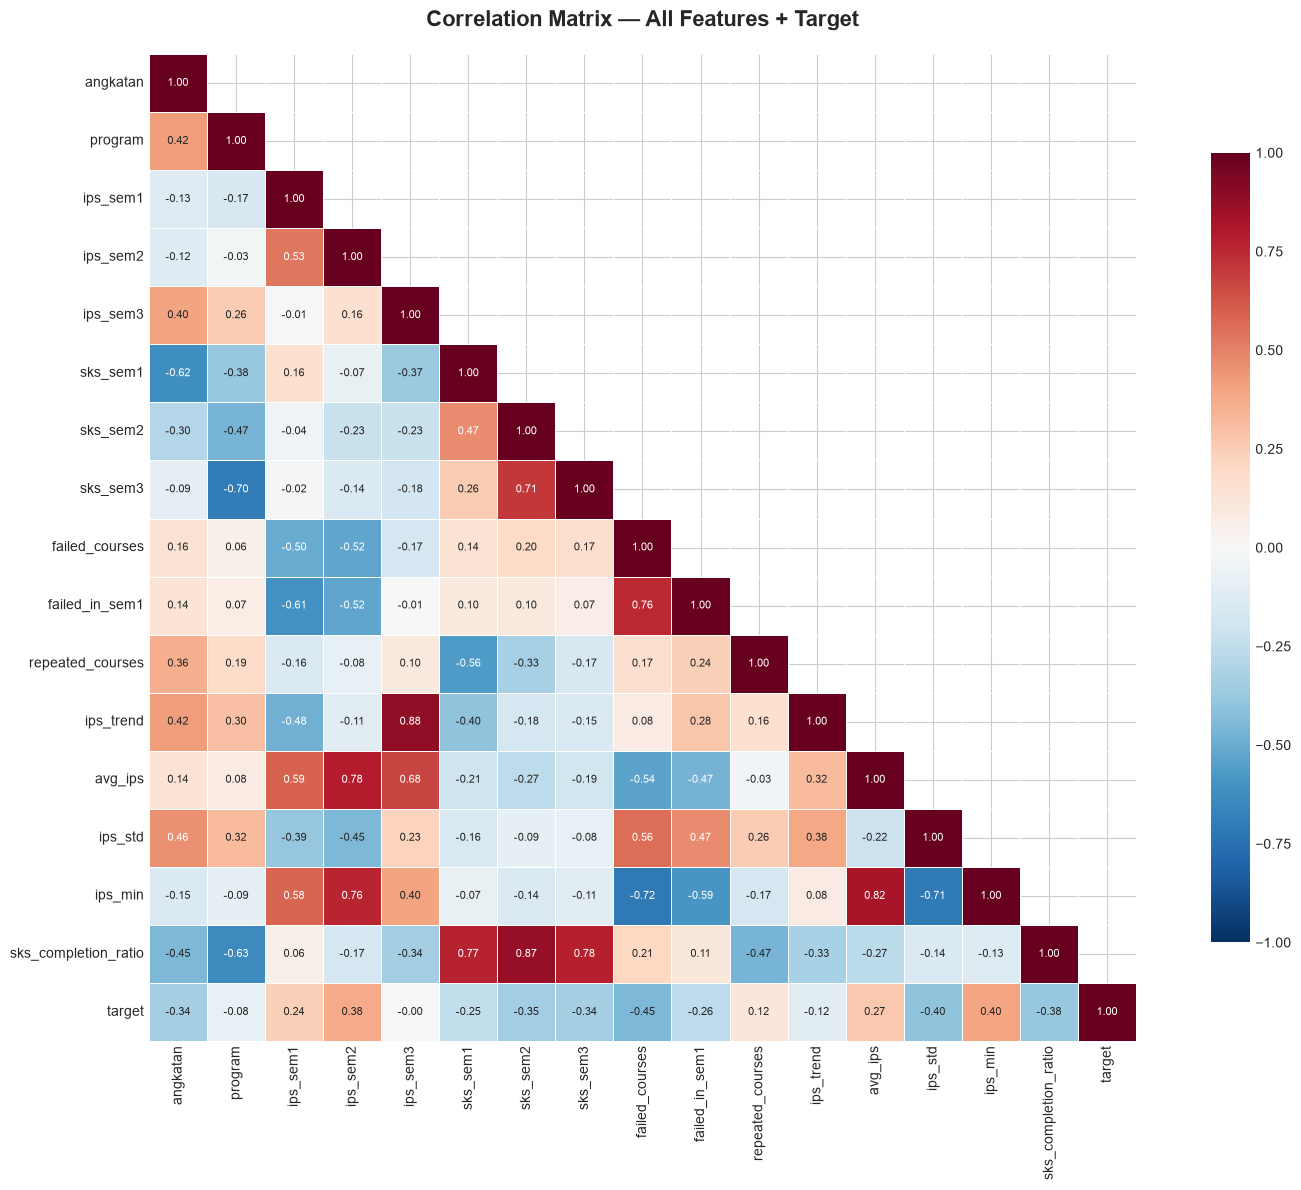

=== Top 10 features correlated with target ===
failed_courses           : -0.4515  (-)
ips_std                  : -0.4044  (-)
ips_min                  : +0.3983  (+)
sks_completion_ratio     : -0.3820  (-)
ips_sem2                 : +0.3753  (+)
sks_sem2                 : -0.3476  (-)
sks_sem3                 : -0.3389  (-)
angkatan                 : -0.3386  (-)
avg_ips                  : +0.2700  (+)
failed_in_sem1           : -0.2583  (-)


In [50]:
# Cell 7: Correlation Heatmap
corr = df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 8})
ax.set_title('Correlation Matrix — All Features + Target',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Highlight top correlations with target
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print('=== Top 10 features correlated with target ===')
for feat, val in target_corr.head(10).items():
    actual_corr = corr.loc[feat, 'target']
    direction = '(+)' if actual_corr > 0 else '(-)'
    print(f'{feat:25s}: {actual_corr:+.4f}  {direction}')


## 8. Top Features vs Target

Korelasi absolut setiap fitur terhadap target. Warna hijau = korelasi positif, merah = negatif.


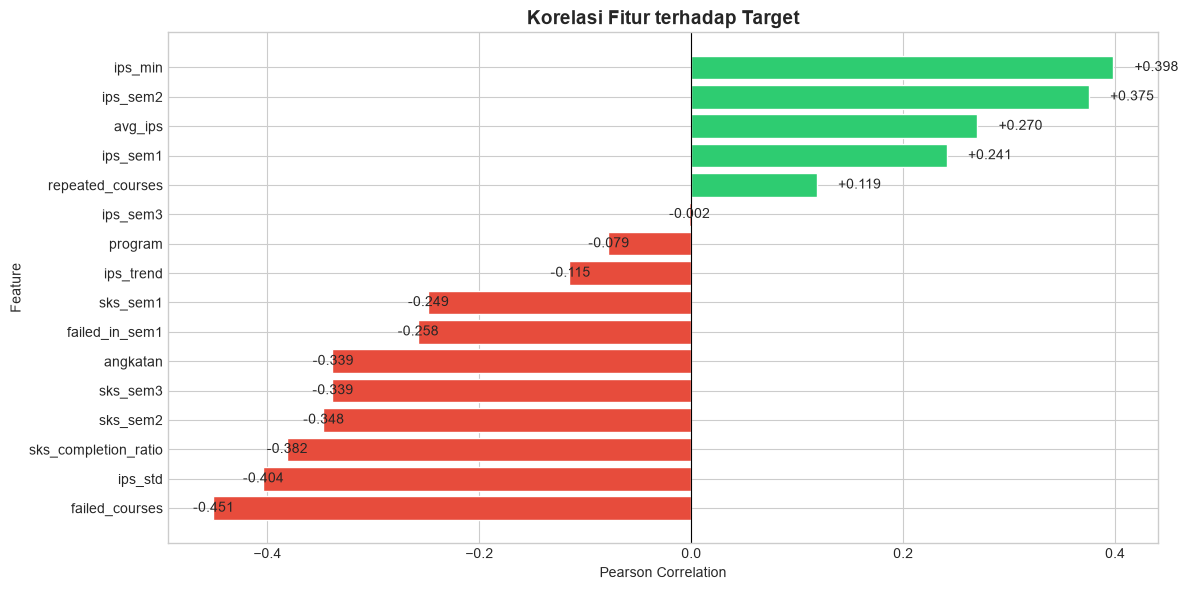

In [51]:
# Cell 8: Top Features vs Target (Bar Chart)
target_corr = df.corr()['target'].drop('target').sort_values()
colors_bar = [COLORS[1] if v >= 0 else COLORS[0] for v in target_corr.values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white')

for bar, val in zip(bars, target_corr.values):
    offset = 0.02 if val >= 0 else -0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(bar.get_width() + offset * (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=10)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


## 9. Pairplot — Key Features

Visualisasi hubungan antar fitur utama: `ips_sem1`, `ips_sem2`, `ips_sem3`, `avg_ips`, `failed_courses`, `ips_trend`.


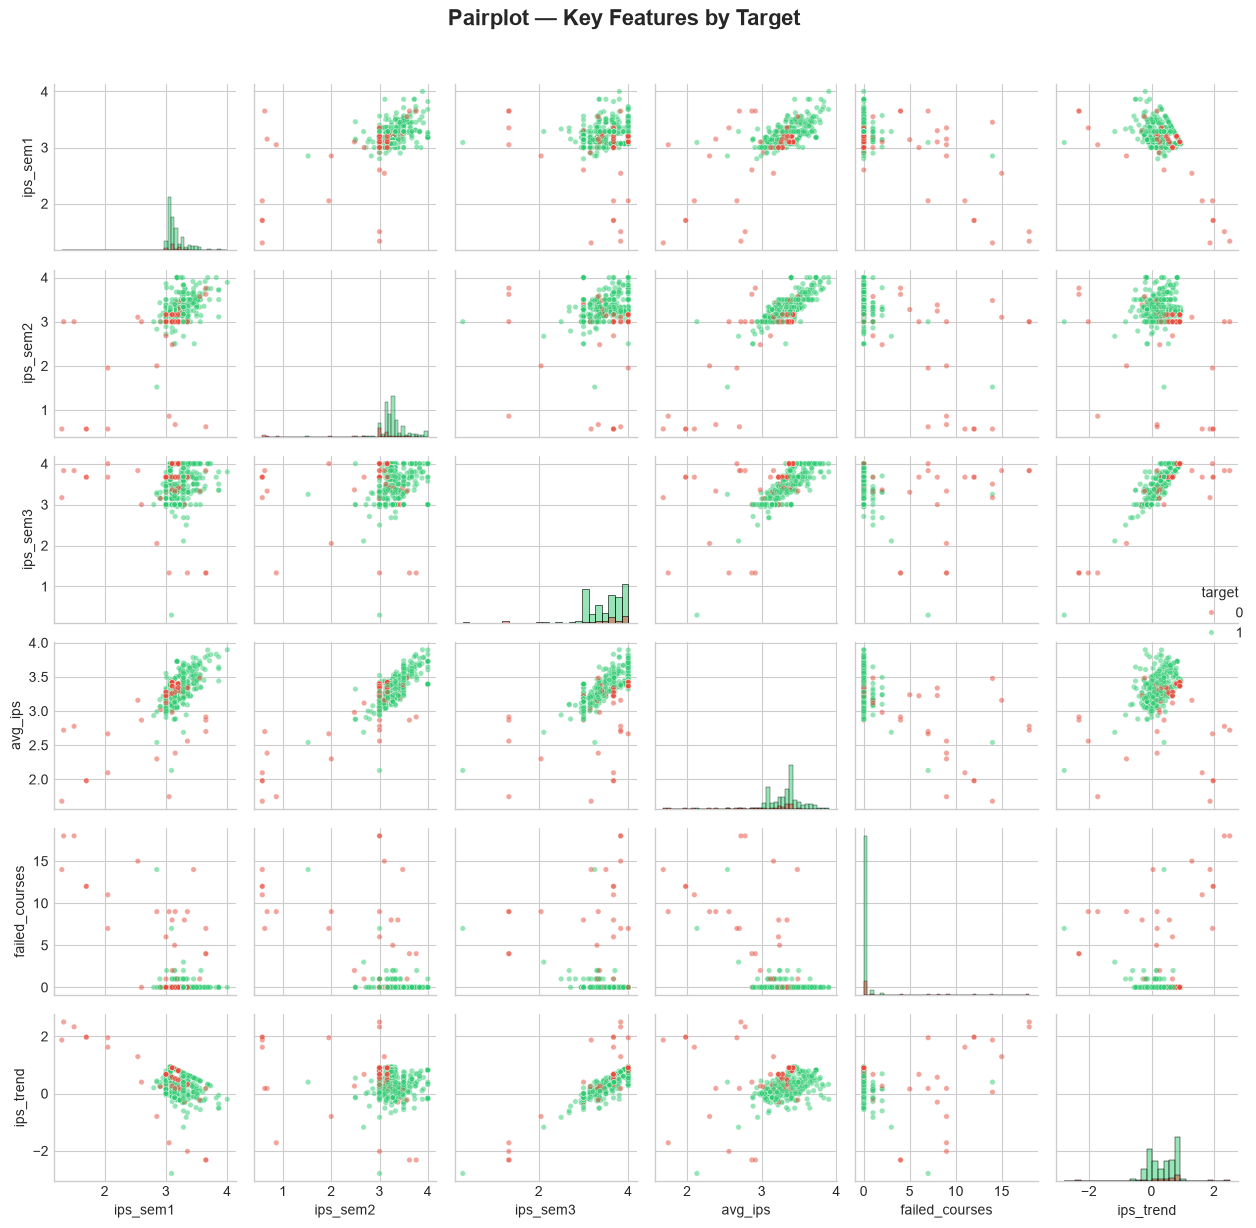

In [52]:
# Cell 9: Pairplot — Key Features
pair_cols = ['ips_sem1', 'ips_sem2', 'ips_sem3', 'avg_ips', 'failed_courses', 'ips_trend', 'target']
sns.pairplot(df[pair_cols], hue='target', palette={0: COLORS[0], 1: COLORS[1]},
             height=2, diag_kind='hist', plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pairplot — Key Features by Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 10. Perbandingan Sebelum vs Sesudah Preprocessing

Tabel perbandingan metrik utama antara dataset mentah (`dataset.csv`) dan dataset bersih (`dataset_clean.csv`).


In [53]:
# Cell 10: Before vs After Comparison
df_orig = pd.read_csv('dataset.csv')
ips1_mean_before = df_orig['ips_sem1'].mean()
nulls_before = df_orig.isnull().sum().sum()

from IPython.display import display, Markdown

comparison = f"""
| Metrik | Before (dataset.csv) | After (dataset_clean.csv) |
|--------|---------------------|--------------------------|
| Jumlah fitur | {df_orig.shape[1]} (dengan string) | {df.shape[1]} (semua numerik) |
| NULLs | {nulls_before} (321 di avg_attendance, dll) | 0 |
| ips_sem1 mean | {ips1_mean_before:.2f} (terkontaminasi 0) | 3.15 (nilai bersih) |
| Data leakage | ips_sem4 (r=0.877) | dihapus |
| Kategorikal | string (AP/IH, L/P, dll) | 0/1 |
| Siap modeling | ❌ | ✅ |
"""
display(Markdown(comparison))



| Metrik | Before (dataset.csv) | After (dataset_clean.csv) |
|--------|---------------------|--------------------------|
| Jumlah fitur | 27 (dengan string) | 17 (semua numerik) |
| NULLs | 2135 (321 di avg_attendance, dll) | 0 |
| ips_sem1 mean | 1.96 (terkontaminasi 0) | 3.15 (nilai bersih) |
| Data leakage | ips_sem4 (r=0.877) | dihapus |
| Kategorikal | string (AP/IH, L/P, dll) | 0/1 |
| Siap modeling | ❌ | ✅ |


## 11. Tabel Fitur Final

Seluruh 16 fitur + 1 target beserta deskripsi.


In [54]:
# Cell 11: Final Feature Table
from IPython.display import display, Markdown

feature_table = """
| # | Feature | Tipe | Range | Deskripsi |
|---|---------|------|-------|-----------|
| 1 | angkatan | int | 2015–2023 | Tahun masuk mahasiswa |
| 2 | program | 0/1 | 0–1 | Program studi (0 = AP/D3, 1 = IH/S1) |
| 3 | ips_sem1 | float | 1.3–4.0 | Indeks Prestasi Semester 1 |
| 4 | ips_sem2 | float | 0.57–4.0 | Indeks Prestasi Semester 2 |
| 5 | ips_sem3 | float | 0.3–4.0 | Indeks Prestasi Semester 3 |
| 6 | sks_sem1 | float | 4.0–133.0 | SKS diambil semester 1 |
| 7 | sks_sem2 | float | 2.0–99.0 | SKS diambil semester 2 |
| 8 | sks_sem3 | float | 6.0–24.0 | SKS diambil semester 3 |
| 9 | failed_courses | int | 0–18 | Jumlah mata kuliah gagal (D/E) |
| 10 | failed_in_sem1 | int | 0–7 | Mata kuliah gagal di semester 1 |
| 11 | repeated_courses | int | 0–12 | Jumlah mata kuliah yang diulang |
| 12 | ips_trend | float | -2.79–2.5 | Tren IPS (koefisien regresi linear) |
| 13 | avg_ips | float | 1.68–3.9 | Rata-rata IPS 3 semester |
| 14 | ips_std | float | 0.0–1.8 | Standar deviasi IPS |
| 15 | ips_min | float | 0.3–3.8 | IPS terendah dari 3 semester |
| 16 | sks_completion_ratio | float | 0.5–2.48 | Rasio SKS lulus / SKS diambil |
| 17 | target | 0/1 | 0–1 | Label: 0 = Tidak Tepat, 1 = Tepat Waktu |
"""
display(Markdown(feature_table))



| # | Feature | Tipe | Range | Deskripsi |
|---|---------|------|-------|-----------|
| 1 | angkatan | int | 2015–2023 | Tahun masuk mahasiswa |
| 2 | program | 0/1 | 0–1 | Program studi (0 = AP/D3, 1 = IH/S1) |
| 3 | ips_sem1 | float | 1.3–4.0 | Indeks Prestasi Semester 1 |
| 4 | ips_sem2 | float | 0.57–4.0 | Indeks Prestasi Semester 2 |
| 5 | ips_sem3 | float | 0.3–4.0 | Indeks Prestasi Semester 3 |
| 6 | sks_sem1 | float | 4.0–133.0 | SKS diambil semester 1 |
| 7 | sks_sem2 | float | 2.0–99.0 | SKS diambil semester 2 |
| 8 | sks_sem3 | float | 6.0–24.0 | SKS diambil semester 3 |
| 9 | failed_courses | int | 0–18 | Jumlah mata kuliah gagal (D/E) |
| 10 | failed_in_sem1 | int | 0–7 | Mata kuliah gagal di semester 1 |
| 11 | repeated_courses | int | 0–12 | Jumlah mata kuliah yang diulang |
| 12 | ips_trend | float | -2.79–2.5 | Tren IPS (koefisien regresi linear) |
| 13 | avg_ips | float | 1.68–3.9 | Rata-rata IPS 3 semester |
| 14 | ips_std | float | 0.0–1.8 | Standar deviasi IPS |
| 15 | ips_min | float | 0.3–3.8 | IPS terendah dari 3 semester |
| 16 | sks_completion_ratio | float | 0.5–2.48 | Rasio SKS lulus / SKS diambil |
| 17 | target | 0/1 | 0–1 | Label: 0 = Tidak Tepat, 1 = Tepat Waktu |
